In [1]:
from langchain_community.document_loaders import PyMuPDFLoader

pdf_path = "document/NIPS-2017-attention-is-all-you-need-Paper.pdf"
docs = PyMuPDFLoader(pdf_path).load_and_split()

In [2]:
len(docs)

12

In [3]:
docs[0]

Document(metadata={'producer': 'PyPDF2', 'creator': '', 'creationdate': '', 'source': 'document/NIPS-2017-attention-is-all-you-need-Paper.pdf', 'file_path': 'document/NIPS-2017-attention-is-all-you-need-Paper.pdf', 'total_pages': 11, 'format': 'PDF 1.3', 'title': 'Attention is All you Need', 'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'keywords': '', 'moddate': '2018-02-12T21:22:10-08:00', 'trapped': '', 'modDate': "D:20180212212210-08'00'", 'creationDate': '', 'page': 0}, page_content='Attention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser

### LLM

In [4]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, streaming=True) # Streaming supported

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


### Vector DB

In [ ]:
# from langchain_community.vectorstores import Chroma # Using Chroma with storing locally

# vectorstore = Chroma.from_documents(
#     documents=docs,
#     embedding=embeddings,
#     collection_name="rag-demo"
# )

In [ ]:
# from langchain_community.vectorstores import Chroma # Using Chroma storing locally

# vectorstore = Chroma.from_documents(
#     documents=docs,
#     embedding=embeddings,
#     collection_name="rag-demo",
#     persist_directory="./chroma_db/rag-demo"
# )

In [ ]:
from langchain_community.vectorstores import Chroma # Using Chroma importing from locally stored database

vectorstore = Chroma(
    embedding_function=embeddings,
    collection_name="rag-demo",
    persist_directory="./chroma_db/rag-demo"
)

/tmp/ipykernel_63314/1227146382.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


### Retriever and its Tool

In [7]:
from langchain_core.tools import create_retriever_tool

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="document_retriever",
    description="Useful for when you need to look up information from the provided document to answer questions.",
)

tools = [retriever_tool]

### Graph State

In [8]:
from typing import Sequence, Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]  # Type-safe + smart reducer

### Nodes

In [9]:

from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = llm

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


In [10]:
from langchain_core.messages import HumanMessage
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = llm
    model = model.bind_tools(tools)
    response = model.invoke(messages)

    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = llm
    response = model.invoke(msg)
    return {"messages": [response]}


def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated state with re-phrased question
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    model = llm

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | model | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}


In [11]:
print("*" * 25 + "Prompt[rlm/rag-prompt]" + "*" * 25)
prompt = hub.pull("rlm/rag-prompt").pretty_print()

*************************Prompt[rlm/rag-prompt]*************************


================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


### Graph

In [12]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(AgentState)

### Add nodes

In [13]:
graph.add_node("agent", agent)

In [14]:
from langgraph.prebuilt import ToolNode, tools_condition

retrieve_node=ToolNode([retriever_tool]) # can be a custom function, custom class, or a prebuilt tool.
graph.add_node("retrieve", retrieve_node)

In [15]:
graph.add_node("rewrite", rewrite)

In [16]:
graph.add_node("generate", generate)

### Add edges to connect nodes

In [17]:
graph.add_edge(START, "agent")

In [18]:
graph.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: END})

In [19]:
graph.add_conditional_edges("retrieve", grade_documents) #{"generate": "generate", "rewrite": "rewrite"}

In [20]:
graph.add_edge("rewrite", "agent")

In [21]:
graph.add_edge("generate", END)

### Compile Graph

In [22]:
graph_compiled = graph.compile()

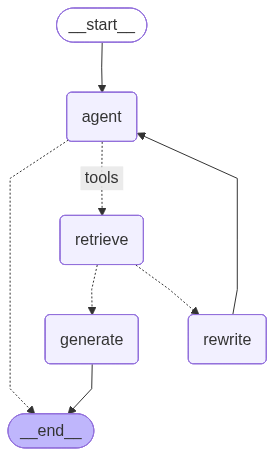

In [23]:
from IPython.display import display, Image

display(Image(graph_compiled.get_graph().draw_mermaid_png()))

### Run the model

In [24]:
import pprint

input_question = "What is the main idea of the paper?"
inputs = {
    "messages": [
        ("user", input_question)
    ]
}

for output in graph_compiled.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("--------------------")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n=====================================\n")

---CALL AGENT---
"Output from node 'agent':"
'--------------------'
{ 'messages': [ AIMessage(content='', additional_kwargs={'function_call': {'name': 'document_retriever', 'arguments': '{"query": "main idea of the paper"}'}, '__gemini_function_call_thought_signatures__': {'b47cf002-551f-4785-a470-f97e768b276d': 'CiQBcsjafEPfpIUoXJXV31w+7EHAhaIHZvbOB2K8BO2xQFg9mEcKZAFyyNp878OQbi2PAOkVcXoQxiIwudAxU8zZd8ctz13hdntfwllm3nA6pWKL6n8sxwvDsAXNfTJWiGeS54M3HgsF0mxJCbHOr2VUwt8qk098KUpvTwNL6nXVyaMBmiwraLt6Tz0KzwEBcsjafFFhZdRZHSVtH5hHjwqN0fuvUXWV/YiLIX/c3KzBV7WXw/EhWu3V1nkUP367oHTYlbA1+YpIer5NS/BhhphU+HxKPgTKCaPL461gA414zSIGmE9nJ8Uh4hX2BeBvI1jLUYLZ+ZW7S084iIRVyWoWqSvnBxzKxL4ybqlWzEOeqKH7gn9brosxS3PeaR5qP8PlmDC5G6HNqQ6WxCgXx23UZE1VZ1QklhdB6jOr0xA09hYOEN5g0bCWjzEoHdE0IAg86PqkRsnUQKPJOns='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019bd20e-e8f6-7701-aa20-53d293430166', tool_calls=[{'name': 'docu

In [26]:
output = graph_compiled.invoke(inputs)

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


In [29]:
type(output), output.keys()

(dict, dict_keys(['messages']))

In [30]:
type(output['messages']), len(output['messages'])

(list, 4)

In [34]:
output['messages'][0].content

'What is the main idea of the paper?'

In [33]:
output['messages'][-1].content

'The main idea of the paper is to propose a novel network architecture called the Transformer, which relies entirely on attention mechanisms and eliminates the need for recurrence and convolutions. This model achieves superior quality in machine translation tasks and is significantly more parallelizable, leading to faster training times. The Transformer sets new state-of-the-art BLEU scores on English-to-German and English-to-French translation tasks.'